**Problem 1:** 

(a) Dataset Generation and Experimental Setup       
Generate a synthetic binary classification dataset as follows:      
* Input space: x = (x1,x2) ∈ R2     
* Number of samples: N = 1000       
* Class labels: y ∈ {0,1}      

Data generation rule:       
y = 1, if (x1^2 +x2^2) > 0.5        
    0, otherwise        
where (x1,x2) are sampled uniformly from [−1,1] × [−1,1].       

Split the dataset into:
* Training set: 80% of the data
* Test set: 20% of the data

Plot the dataset and explain why a linear classifier cannot solve this problem.

In [248]:
import numpy as np

In [249]:
X = np.random.uniform(low=-1, high=1, size=(1000, 2))


In [250]:
# y = [1 if x1**2+x2**2>0.5 else 0 for x1,x2 in zip(X1, X2)]
y = np.array([(x1**2+x2**2>0.5).astype(int) for x1,x2 in X])
y

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,

In [251]:
test_size = 0.2
test_length:int = int(test_size * len(X))
train_length:int = int(len(X) - test_length)

# Training set
X_train = X[:train_length]

y_train = y[:train_length]

# Test set
X_test = X[train_length:]

y_test = y[train_length:]

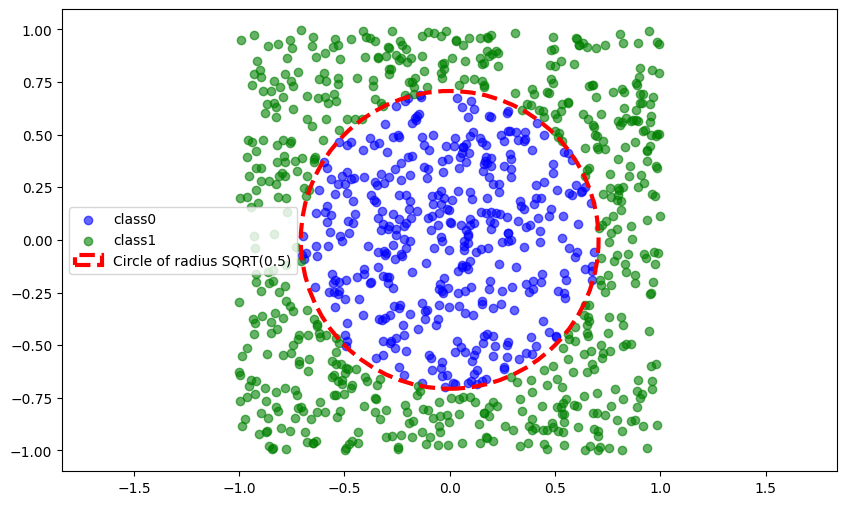

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color="blue", label="class0", alpha=0.6)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color="green", label="class1", alpha=0.6)

circle = plt.Circle((0,0), np.sqrt(0.5), color="red",fill=False, linestyle="--", label="Circle of radius SQRT(0.5)", linewidth=3)

plt.gca().add_patch(circle)
plt.axis("equal")
plt.legend()
plt.show()

Given constraint is x1^2+x2^2 > 0.5 

This equation represents equation of a circle with radius 0.5

Any point within the circle is marked as 0.     
Any point outside the circle is marked as 1.        

Linear Classifier cannot solve this problem as this constraint cannot be applied using a linear boundary.

(b) Neural Network Architectures    
Implement the following two neural networks:        

Model 1 (Shallow Network):      
• Input layer: 2 neurons        
• One hidden layer: 20 neurons      
• Output layer: 1 neuron        

Model 2 (Deeper Network):       
• Input layer: 2 neurons        
• Hidden layer 1: 10 neurons        
• Hidden layer 2: 10 neurons        
• Output layer: 1 neuron        

Both models must use:       
• ReLU activation in hidden layers      
• Sigmoid activation in the output layer        

In [253]:
import numpy as np

np.random.seed(42)

In [254]:
# Activation Functions
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x>0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1-s)

In [255]:
class ShallowNN:
    def __init__(self, hidden_size, input_size, output_size, weight_low=0, weight_high=0.01):
        self.W1 = np.random.normal(weight_low, weight_high, (hidden_size, input_size))
        #self.b1 = np.random.normal(-1, 1, (hidden_size, 1))
        self.b1 = np.zeros((hidden_size, 1))

        self.W2 = np.random.normal(weight_low, weight_high, (output_size, hidden_size))
        #self.b2 = np.random.normal(-1, 1, (output_size, 1))
        self.b2 = np.zeros((output_size, 1))
        pass

    def __str__(self):
        return f"W1: {self.W1}, b1: {self.b1}, W2: {self.W2}, b2: {self.b2}"

    def binary_cross_entropy(self, y_pred, y_true):
        epsilon = 1e-8  # for numerical stability
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def forward(self, x):
        x = np.array(x).reshape(-1, 1)
        # Hidden Layer
        self.z1 = np.dot(self.W1, x) + self.b1
        self.a1 = relu(self.z1)

        # Output Layer
        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = sigmoid(self.z2)
        # Forward pass
        # self.z1 = np.dot(x, self.W1.T) + self.b1.T   # (batch_size, hidden_size)
        # self.a1 = relu(self.z1)

        # self.z2 = np.dot(self.a1, self.W2.T) + self.b2.T  # (batch_size, output_size)
        # self.a2 = sigmoid(self.z2)

        return self.a2
    
    def backward(self, x, y, lr=0.01):
        x = np.array(x).reshape(-1, 1)
        y = np.array(y).reshape(-1, 1)

        # Output Layer error
        dz2 = (self.a2 - y) * sigmoid_derivative(self.z2)
        dW2 = np.dot(dz2, self.a1.T)
        db2 = dz2

        # Hidden Layer error
        dz1 = np.dot(self.W2.T, dz2) * relu_derivative(self.z1)
        dW1 = np.dot(dz1, x.T)
        db1 = dz1

         # Update weights and biases
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1
        
    def train(self, X, Y, epochs=1000, lr=0.01):
        for epoch in range(epochs):
            total_loss = 0
            for x,y in zip(X, Y):
                y_pred = self.forward(x)
                self.backward(x, y, lr)
                total_loss += self.binary_cross_entropy(y_pred, np.array(y).reshape(-1,1))
            if epoch % 10 == 0:
                print(f"Epoch {epoch}, Loss: {total_loss / len(X):.4f}")

In [256]:
# Model 2 - with two hidden layers
class DeepNN:
    def __init__(self, hidden1_size, hidden2_size, input_size, output_size, weight_low=0, weight_high=0.01):
        # First hidden layer
        self.W1 = np.random.normal(weight_low, weight_high, (hidden1_size, input_size))
        self.b1 = np.zeros((hidden1_size, 1))
        
        
        # Second hidden layer
        self.W2 = np.random.normal(weight_low, weight_high, (hidden2_size, hidden1_size))
        self.b2 = np.zeros((hidden2_size, 1))
        
        # Output layer
        self.W3 = np.random.normal(weight_low, weight_high, (output_size, hidden2_size))
        self.b3 = np.zeros((output_size, 1))

    def __str__(self):
        return f"W1: {self.W1}, b1: {self.b1}, W2: {self.W2}, b2: {self.b2}, W3: {self.W3}, b2: {self.b3} "

    def binary_cross_entropy(self, y_pred, y_true):
        epsilon = 1e-8  # for numerical stability
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def forward(self, x):
        x = np.array(x).reshape(-1, 1)

        # Hidden Layer 1
        self.z1 = np.dot(self.W1, x) + self.b1
        self.a1 = relu(self.z1)

        # Hidden Layer 2
        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = relu(self.z2)

        # Output Layer
        self.z3 = np.dot(self.W3, self.a2) + self.b3
        self.a3 = sigmoid(self.z3)

        return self.a3
    
    def backward(self, x, y, lr=0.01):
        x = np.array(x).reshape(-1, 1)
        y = np.array(y).reshape(-1, 1)

        # Output layer error
        dz3 = (self.a3 - y) * sigmoid_derivative(self.z3)
        dW3 = np.dot(dz3, self.a2.T)
        db3 = dz3

        # Hidden layer 2 error
        dz2 = np.dot(self.W3.T, dz3) * relu_derivative(self.z2)
        dW2 = np.dot(dz2, self.a1.T)
        db2 = dz2

        # Hidden layer 1 error
        dz1 = np.dot(self.W2.T, dz2) * relu_derivative(self.z1)
        dW1 = np.dot(dz1, x.T)
        db1 = dz1

        # Update weights and biases
        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def train(self, X, Y, epochs=1000, lr=0.01):
        for epoch in range(epochs):
            total_loss = 0
            for x,y in zip(X, Y):
                y_pred = self.forward(x)
                self.backward(x, y, lr)
                total_loss += self.binary_cross_entropy(y_pred, np.array(y).reshape(-1,1))
            if epoch%10==0:
                print(f"Epoch {epoch}, Loss: {total_loss / len(X):.4f}")


In [257]:
import numpy as np

# Hyperparameters
lr = 0.01
epochs = 100

print(X_train.shape)
print(y_train.shape)


(800, 2)
(800,)


In [258]:
one_hidden = ShallowNN(input_size=2, hidden_size=20, output_size=1)
two_hidden = DeepNN(input_size=2, hidden1_size=10, hidden2_size=10, output_size=1)

In [259]:

losses_one = []
losses_two = []

for epoch in range(epochs):
    # One-hidden-layer model
    for x,y in zip(X_train, y_train):
        y_pred1 = one_hidden.forward(x)
        loss1 = one_hidden.binary_cross_entropy(y_pred1, y)
        one_hidden.backward(x, y, lr)
        losses_one.append(loss1)

    # Two-hidden-layer model
    for x,y in zip(X_train, y_train):
        y_pred2 = two_hidden.forward(x)
        loss2 = two_hidden.binary_cross_entropy(y_pred2, y)
        two_hidden.backward(x, y, lr)
        losses_two.append(loss2)


TypeError: 'str' object is not callable

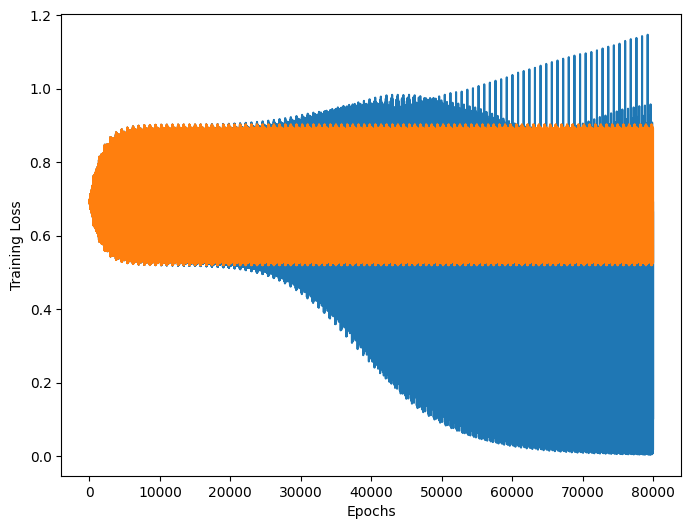

In [260]:
# --- Plot losses --- 
plt.figure(figsize=(8,6)) 
plt.plot(losses_one, label="Shallow NN (20 hidden)") 
plt.plot(losses_two, label="Deep NN (10+10 hidden)") 
plt.xlabel("Epochs") 
plt.ylabel("Training Loss") 
plt.title("Training Loss vs Epochs") 
plt.legend() 
plt.grid(True) 
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

# Evaluate model one sample at a time
y_preds = []
for x, y in zip(X_test, y_test):
    y_pred = one_hidden.forward(x)       # forward pass
    y_label = int(y_pred > 0.5)     # threshold at 0.5
    y_preds.append(y_label)

# Convert to numpy array
y_preds = np.array(y_preds)

# Compute accuracy
acc = accuracy_score(y_test, y_preds)
print("Accuracy:", acc)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:\n", cm)


Accuracy: 0.96
Confusion Matrix:
 [[ 66   7]
 [  1 126]]


C:\Users\ankit\AppData\Local\Temp\ipykernel_20800\3890603643.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_label = int(y_pred > 0.5)     # threshold at 0.5


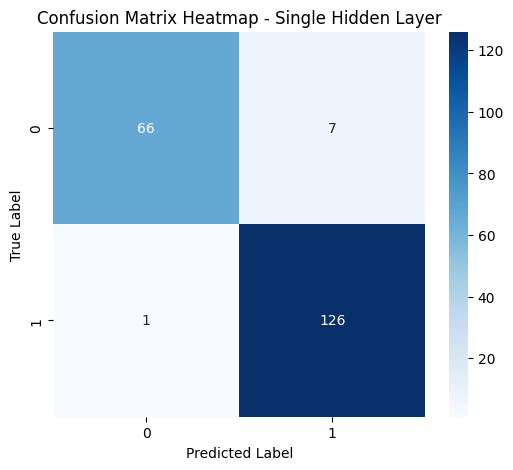

In [ ]:
import seaborn as sns

# Plot heatmap 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1]) 
plt.xlabel("Predicted Label") 
plt.ylabel("True Label") 
plt.title("Confusion Matrix Heatmap - Single Hidden Layer") 
plt.show()

In [ ]:
# Evaluate model one sample at a time
y_preds = []
for x, y in zip(X_test, y_test):
    y_pred = two_hidden.forward(x)       # forward pass
    y_label = int(y_pred > 0.5)     # threshold at 0.5
    y_preds.append(y_label)

# Convert to numpy array
y_preds = np.array(y_preds)

# Compute accuracy
acc = accuracy_score(y_test, y_preds)
print("Accuracy:", acc)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:\n", cm)

Accuracy: 0.635
Confusion Matrix:
 [[  0  73]
 [  0 127]]


C:\Users\ankit\AppData\Local\Temp\ipykernel_20800\1181626526.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_label = int(y_pred > 0.5)     # threshold at 0.5


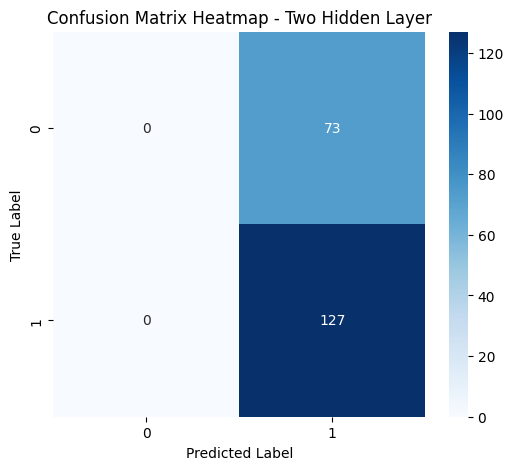

In [ ]:
import seaborn as sns

# Plot heatmap 
plt.figure(figsize=(6,5)) 
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1]) 
plt.xlabel("Predicted Label") 
plt.ylabel("True Label") 
plt.title("Confusion Matrix Heatmap - Two Hidden Layer") 
plt.show()

### 1. Representational Capacity
- **Shallow Network (20 neurons, 1 hidden layer)**  
  - Already has enough capacity to approximate nonlinear boundaries like the circle in dataset.  
  - With sufficient neurons, a single hidden layer can approximate *any* continuous function (Universal Approximation Theorem).  
  - However, it may require more neurons than a deeper network to capture complex patterns efficiently.

- **Deep Network (10 + 10 neurons, 2 hidden layers)**  
  - Greater representational power with fewer neurons per layer.  
  - Depth allows hierarchical feature extraction: the first hidden layer can learn simple transformations, the second can combine them into more complex representations.  
  - More efficient at modeling intricate decision boundaries compared to a shallow network with the same total number of neurons.

---

### 🔹 2. Optimization Difficulty
- **Shallow Network**  
  - Easier to train: fewer layers mean fewer parameters and simpler gradient flow.  
  - Less prone to vanishing/exploding gradients.  
  - Training is faster and more stable.

- **Deep Network**  
  - Harder to optimize: more layers -> deeper gradient chains -> higher risk of vanishing/exploding gradients.  
  - Requires careful initialization ($N(0,0.01)$) and possibly techniques like batch normalization or adaptive optimizers for stability.  
  - Training time is longer due to more parameters and computations.

---

### 🔹 3. Generalization Performance
- **Shallow Network**  
  - Can generalize well on moderately complex tasks like circular boundary.  
  - Risk of underfitting if the problem requires hierarchical feature learning beyond what a single layer can capture.  
  - Often sufficient for simple synthetic datasets.

- **Deep Network**  
  - Potentially better generalization on complex, high-dimensional tasks.  
  - But with small datasets (like 1000 samples), deeper networks risk overfitting unless regularization is applied.  
  
---

**Problem 4** Code the Activation Functions     
1. Create a class or set of functions in Python (using numpy) for the following activation functions:
Sigmoid: σ(x) = 1/1+e−x      
Tanh: tanh(x) = 1−e−2x/1+e−2x        
ReLU: max(0,x)       
Leaky ReLU: x if x > 0, else αx (use α = 0.01)      
2. Implement the derivative for each function.      
3. Visualization: Generate a range of inputs from-5 to 5. Plot each activation function and its corresponding derivative on the same graph.     

In [ ]:
import numpy as np

# 1. Create a class or set of functions for Sigmoid, Tanh, ReLU, Leaky ReLU
def sigmoid(x):
    return (1/(1+np.exp(-x)))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return max(0, x)

def leaky_relu(x):
    return x if x>0 else 0.01*x #alpha=0.01

# 2. Derivatives of each function
def derivative_sigmoid(x):
    s = sigmoid(x)
    return s * (1-s)

def derivative_tanh(x):
    return 1 - np.tanh(x)**2

def derivative_relu(x):
    return 1 if x>0 else 0

def derivative_leaky_relu(x):
    return 1 if x>0 else 0.01 # alpha=0.01


In [ ]:
X = np.linspace(-5, 5, 11)

sigma_x = [sigmoid(x) for x in X]
sigma_dx = [derivative_sigmoid(x) for x in X]
tanh_x = [tanh(x) for x in X]
tanh_dx = [derivative_tanh(x) for x in X]
relu_x = [relu(x) for x in X]
relu_dx = [derivative_leaky_relu(x) for x in X]
leaky_relu_x = [leaky_relu(x) for x in X]
leaky_relu_dx = [derivative_leaky_relu(x) for x in X]


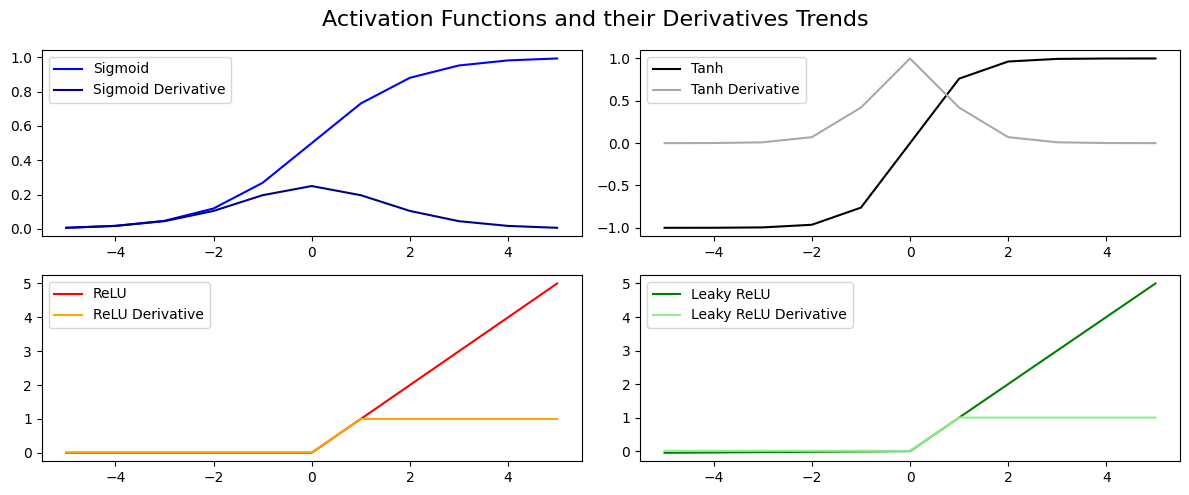

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.title = "Activation Functions"
plt.plot(x, sigma_x, label="Sigmoid", color="blue")
plt.plot(x, sigma_dx, label="Sigmoid Derivative", color="darkblue")
plt.legend()

plt.subplot(2,2,2)
plt.plot(x, tanh_x, label="Tanh", color="black")
plt.plot(x, tanh_dx, label="Tanh Derivative", color="darkgray")
plt.legend()

plt.subplot(2,2,3)
plt.plot(x, relu_x, label="ReLU", color="red")
plt.plot(x, relu_dx, label="ReLU Derivative", color="orange")
plt.legend()

plt.subplot(2,2,4)
plt.plot(x, leaky_relu_x, label="Leaky ReLU", color="green")
plt.plot(x, leaky_relu_dx, label="Leaky ReLU Derivative", color="lightgreen")

plt.legend()
plt.suptitle("Activation Functions and their Derivatives Trends", fontsize=16)
plt.tight_layout()
plt.show()


**Problem 7**

In [ ]:
#  (a) Implement forward propagation and manual backpropagation using NumPy.
import numpy as np

# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# Synthetic dataset: 20 samples, x1,x2 ~ Uniform(-1,1), y = x1^2 + x2^2
np.random.seed(42)
X = np.random.uniform(-1, 1, (20, 2))
y = np.sum(X**2, axis=1, keepdims=True)

# Initialize parameters
W1 = np.random.randn(5, 2) * 0.01
b1 = np.random.randn(5, 1) * 0.01
W2 = np.random.randn(1, 5) * 0.01
b2 = np.random.randn(1, 1) * 0.01

In [ ]:
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1.T + b1.T        # (20,5)
    H = sigmoid(Z1)             # hidden activations
    y_hat = H @ W2.T + b2       # (20,1)
    return Z1, H, y_hat

def loss(y, y_hat):
    return 0.5 * np.mean((y_hat - y)**2)

In [ ]:
def backward(X, y, Z1, H, y_hat, W2):
    m = X.shape[0]
    dL_dyhat = (y_hat - y) / m
    
    dW2 = dL_dyhat.T @ H
    db2 = np.sum(dL_dyhat, axis=0, keepdims=True).T
    
    dH = dL_dyhat @ W2
    dZ1 = dH * sigmoid_derivative(Z1)
    
    dW1 = dZ1.T @ X
    db1 = np.sum(dZ1, axis=0, keepdims=True).T
    
    return dW1, db1, dW2, db2

In [ ]:
# (b) Implement gradient checking using finite difference approximation:
def gradient_check(X, y, W1, b1, W2, b2, epsilon=1e-5):
    Z1, H, y_hat = forward(X, W1, b1, W2, b2)
    dW1, db1, dW2, db2 = backward(X, y, Z1, H, y_hat, W2)
    grads = {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}
    
    checks = []
    # (c) Compare analytical gradients obtained using backpropagation with numerical gradients
    # for at least three randomly chosen parameters
    for name, param in [("W1", W1), ("b1", b1), ("W2", W2), ("b2", b2)]:
        i = np.random.randint(param.shape[0])
        j = np.random.randint(param.shape[1])
        
        param_plus = param.copy(); param_plus[i,j] += epsilon
        param_minus = param.copy(); param_minus[i,j] -= epsilon
        
        if name == "W1":
            _, _, y_hat_plus = forward(X, param_plus, b1, W2, b2)
            _, _, y_hat_minus = forward(X, param_minus, b1, W2, b2)
        elif name == "b1":
            _, _, y_hat_plus = forward(X, W1, param_plus, W2, b2)
            _, _, y_hat_minus = forward(X, W1, param_minus, W2, b2)
        elif name == "W2":
            _, _, y_hat_plus = forward(X, W1, b1, param_plus, b2)
            _, _, y_hat_minus = forward(X, W1, b1, param_minus, b2)
        else: # b2
            _, _, y_hat_plus = forward(X, W1, b1, W2, param_plus)
            _, _, y_hat_minus = forward(X, W1, b1, W2, param_minus)
        
        L_plus = loss(y, y_hat_plus)
        L_minus = loss(y, y_hat_minus)
        grad_num = (L_plus - L_minus) / (2 * epsilon)
        
        grad_ana = grads[name][i,j]
        rel_error = np.abs(grad_num - grad_ana) / (np.maximum(1e-8, np.abs(grad_num) + np.abs(grad_ana)))
        
        checks.append((name, (i,j), grad_num, grad_ana, rel_error))
    return checks

# (d) Report the relative error between analytical and numerical gradients and comment on
# the correctness of your implementation.
# Run gradient check
checks = gradient_check(X, y, W1, b1, W2, b2)
for name, idx, grad_num, grad_ana, rel_error in checks:
    print(f"{name}{idx}: Numerical={grad_num:.6f}, Analytical={grad_ana:.6f}, RelError={rel_error:.6e}")


W1(2, 0): Numerical=-0.000910, Analytical=-0.000910, RelError=1.097243e-09
b1(0, 0): Numerical=-0.001866, Analytical=-0.001866, RelError=6.819066e-10
W2(0, 2): Numerical=-0.349821, Analytical=-0.349821, RelError=4.702855e-12
b2(0, 0): Numerical=-0.706078, Analytical=-0.706078, RelError=5.602390e-13


- Relative error should be very small (typically < $10^−7$).

- If errors are large, it indicates a bug in backpropagation implementation.

- Gradient checking is performed before training to validate correctness.

**Problem 8**
----------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 20
sigma = 0.1

X = np.random.uniform(0, 2*np.pi, n)
y_true = np.sin(X)
y = y_true + np.random.normal(0, sigma, n)

# Reshape for sklearn
X = X.reshape(-1,1)

X

array([[2.35330497],
       [5.97351416],
       [4.59925358],
       [3.76148219],
       [0.98029403],
       [0.98014248],
       [0.3649501 ],
       [5.44234523],
       [3.77691701],
       [4.44895122],
       [0.12933619],
       [6.09412333],
       [5.23039137],
       [1.33416598],
       [1.14243996],
       [1.15236452],
       [1.91161039],
       [3.2971419 ],
       [2.71399059],
       [1.82984665]])

Problem 8.1. Linear Hypothesis        
----------------------

Assume the hypothesis class is linear:      
ˆ y =Wx+c.      
(a) Fit the model to the sampled data.      
(b) Report the training & testing error. Visualize the learned hypothesis along with the true function and sampled points.      
(c) Experiment with different values of W and c (either manually or via least-squares fitting).     
(d) Comment on the bias and variance of this model with respect to the true function.       

Linear Model: Train Error = 0.23460112322056922 Test Error = 0.20023532067181532


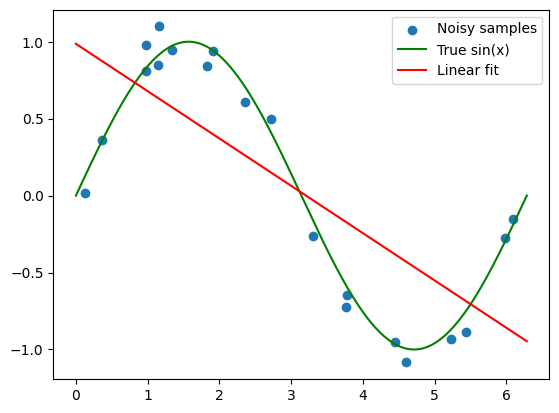

In [ ]:
# Problem 8.1 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_train = lin_reg.predict(X)

# Test on dense grid
X_test = np.linspace(0, 2*np.pi, 200).reshape(-1,1)
y_test_true = np.sin(X_test)
y_pred_test = lin_reg.predict(X_test)

train_error = mean_squared_error(y, y_pred_train)
test_error = mean_squared_error(y_test_true, y_pred_test)

print("Linear Model: Train Error =", train_error, "Test Error =", test_error)

# Visualization
plt.scatter(X, y, label="Noisy samples")
plt.plot(X_test, y_test_true, label="True sin(x)", color="green")
plt.plot(X_test, y_pred_test, label="Linear fit", color="red")
plt.legend()
plt.title = "Linear Hypothesis"
plt.show()


- The linear model has high bias (it cannot capture the sinusoidal shape).

- Variance is low (predictions don’t fluctuate much across datasets).

Problem 8.2. Polynomial Hypothesis      
----------------------

Now consider a polynomial hypothesis of degree d:

y = $\sum_{k=0}^{d} w_{k}x^k$.        
        
(a) Fit polynomial models for increasing values of d (e.g., d = 3,5,10).        
(b) Report the training & testing error. Visualize the fitted polynomials along with the true function and sampled data.        
(c) Observe the behavior of the learned function as the degree increases.       
(d) Comment on how bias and variance change as model complexity increases.      

Degree 3: Train Error = 0.0063, Test Error = 0.0078


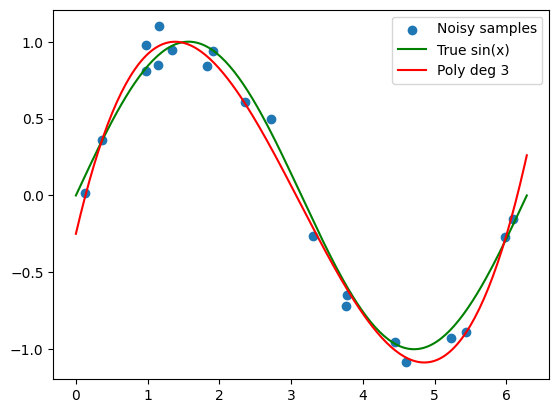

Degree 5: Train Error = 0.0053, Test Error = 0.0042


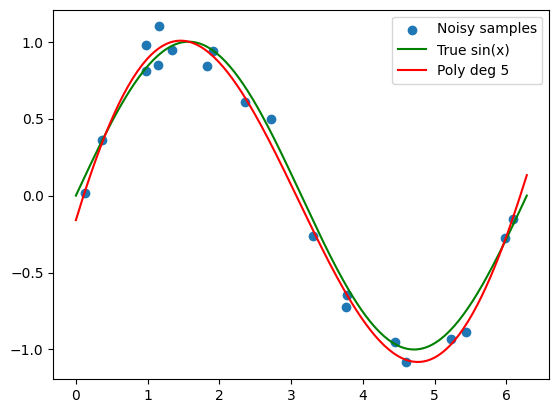

Degree 10: Train Error = 0.0041, Test Error = 0.0052


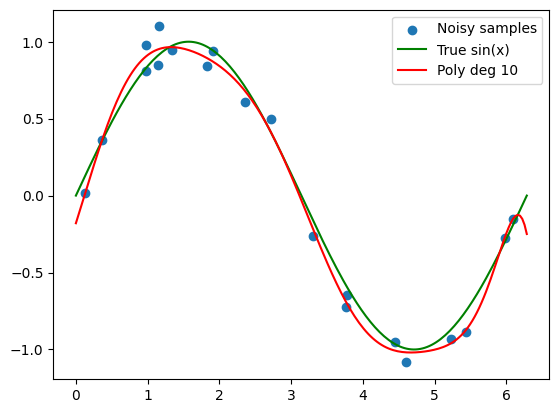

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees = [3, 5, 10]
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X, y)
    
    y_pred_train = model.predict(X)
    y_pred_test = model.predict(X_test)
    
    train_error = mean_squared_error(y, y_pred_train)
    test_error = mean_squared_error(y_test_true, y_pred_test)
    
    print(f"Degree {d}: Train Error = {train_error:.4f}, Test Error = {test_error:.4f}")
    
    plt.scatter(X, y, label="Noisy samples")
    plt.plot(X_test, y_test_true, label="True sin(x)", color="green")
    plt.plot(X_test, y_pred_test, label=f"Poly deg {d}", color="red")
    plt.legend()
    plt.title=f"Polynomial Hypothesis (degree {d})"
    plt.show()


Low degree (d=3):
----------------------

- Moderate bias (can capture curvature better than linear).

- Low variance.

Medium degree (d=5):
----------------------

- Bias decreases further, closer to sin (𝑥)

- Variance increases slightly.

High degree (d=10):
----------------------

- Very low bias (fits training data almost perfectly).

- High variance (overfits noise, poor generalization).

Bias–Variance Tradeoff
----------------------

- Linear model: High bias, low variance.
- Polynomial models: As degree increases, bias decreases but variance increases.
- Optimal complexity: Somewhere in the middle (e.g., degree 5) balances bias and variance.

Problem 11. 
------------
Implement a two-layer neural network with 2 input neurons, 10 hidden neurons, and 1 out put neuron using ReLU activation in the hidden layer to solve the XOR classification problem. Investigate how the learning rate and bias initialization affect the dying ReLU phenomenon.Weights are initialized as  Wij ∼ N(0,0.01)
unless stated otherwise.
Tasks
1. Train the network under the following five configurations:
• Case 1: Learning rate = 0.1, Bias initialization =-5.0, Epochs = 500
• Case 2: Learning rate = 0.1, Bias initialization = 0.0, Epochs = 500
• Case 3: Learning rate = 0.01, Bias initialization =-5.0, Epochs = 500
• Case 4: Learning rate = 0.01, Bias initialization = 0.0, Epochs = 500
• Case 5: Learning rate = 0.01, Bias initialization = random, Epochs = 10000
2. For each configuration, plot a grid of figures showing:
• Row 1: Training loss versus epochs
• Row 2: Fraction of dead hidden neurons versus e

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ReLU activation
def relu(z): return np.maximum(0, z)
def relu_derivative(z): return (z > 0).astype(float)

# Sigmoid for output
def sigmoid(z): return 1 / (1 + np.exp(-z))

# Initialize parameters
def init_params(bias_init=0.0, random_bias=False):
    W1 = np.random.normal(0, 0.01, (10, 2))
    if random_bias:
        b1 = np.random.randn(10, 1)   # random bias init
    else:
        b1 = np.ones((10,1)) * bias_init
    W2 = np.random.normal(0, 0.01, (1, 10))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2

# Forward pass
def forward(X, W1, b1, W2, b2):
    Z1 = W1 @ X.T + b1
    H = relu(Z1)
    Z2 = W2 @ H + b2
    y_hat = sigmoid(Z2)
    return Z1, H, Z2, y_hat

# Loss (binary cross-entropy)
def loss(y, y_hat):
    m = y.shape[0]
    return -np.mean(y*np.log(y_hat.T+1e-8) + (1-y)*np.log(1-y_hat.T+1e-8))

# Backpropagation
def backward(X, y, Z1, H, Z2, y_hat, W2):
    m = X.shape[0]
    dZ2 = (y_hat.T - y) / m
    dW2 = dZ2.T @ H.T
    db2 = np.sum(dZ2, axis=0, keepdims=True).T
    
    dH = dZ2 @ W2
    dZ1 = dH.T * relu_derivative(Z1)
    dW1 = dZ1 @ X
    db1 = np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

# Training loop with metrics
def train(X, y, lr, epochs, bias_init=0.0, random_bias=False, label=""):
    W1, b1, W2, b2 = init_params(bias_init, random_bias)
    losses, dead_fractions, accuracies = [], [], []
    
    for epoch in range(epochs):
        Z1, H, Z2, y_hat = forward(X, W1, b1, W2, b2)
        L = loss(y, y_hat)
        losses.append(L)
        
        # Dead neurons fraction
        dead_fraction = np.mean(np.all(H == 0, axis=1))
        dead_fractions.append(dead_fraction)
        
        # Accuracy
        preds = (y_hat.T > 0.5).astype(int)
        acc = np.mean(preds == y)
        accuracies.append(acc)
        
        # Backprop
        dW1, db1_grad, dW2, db2_grad = backward(X, y, Z1, H, Z2, y_hat, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_grad
        W2 -= lr * dW2
        b2 -= lr * db2_grad
    
    return losses, dead_fractions, accuracies

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])


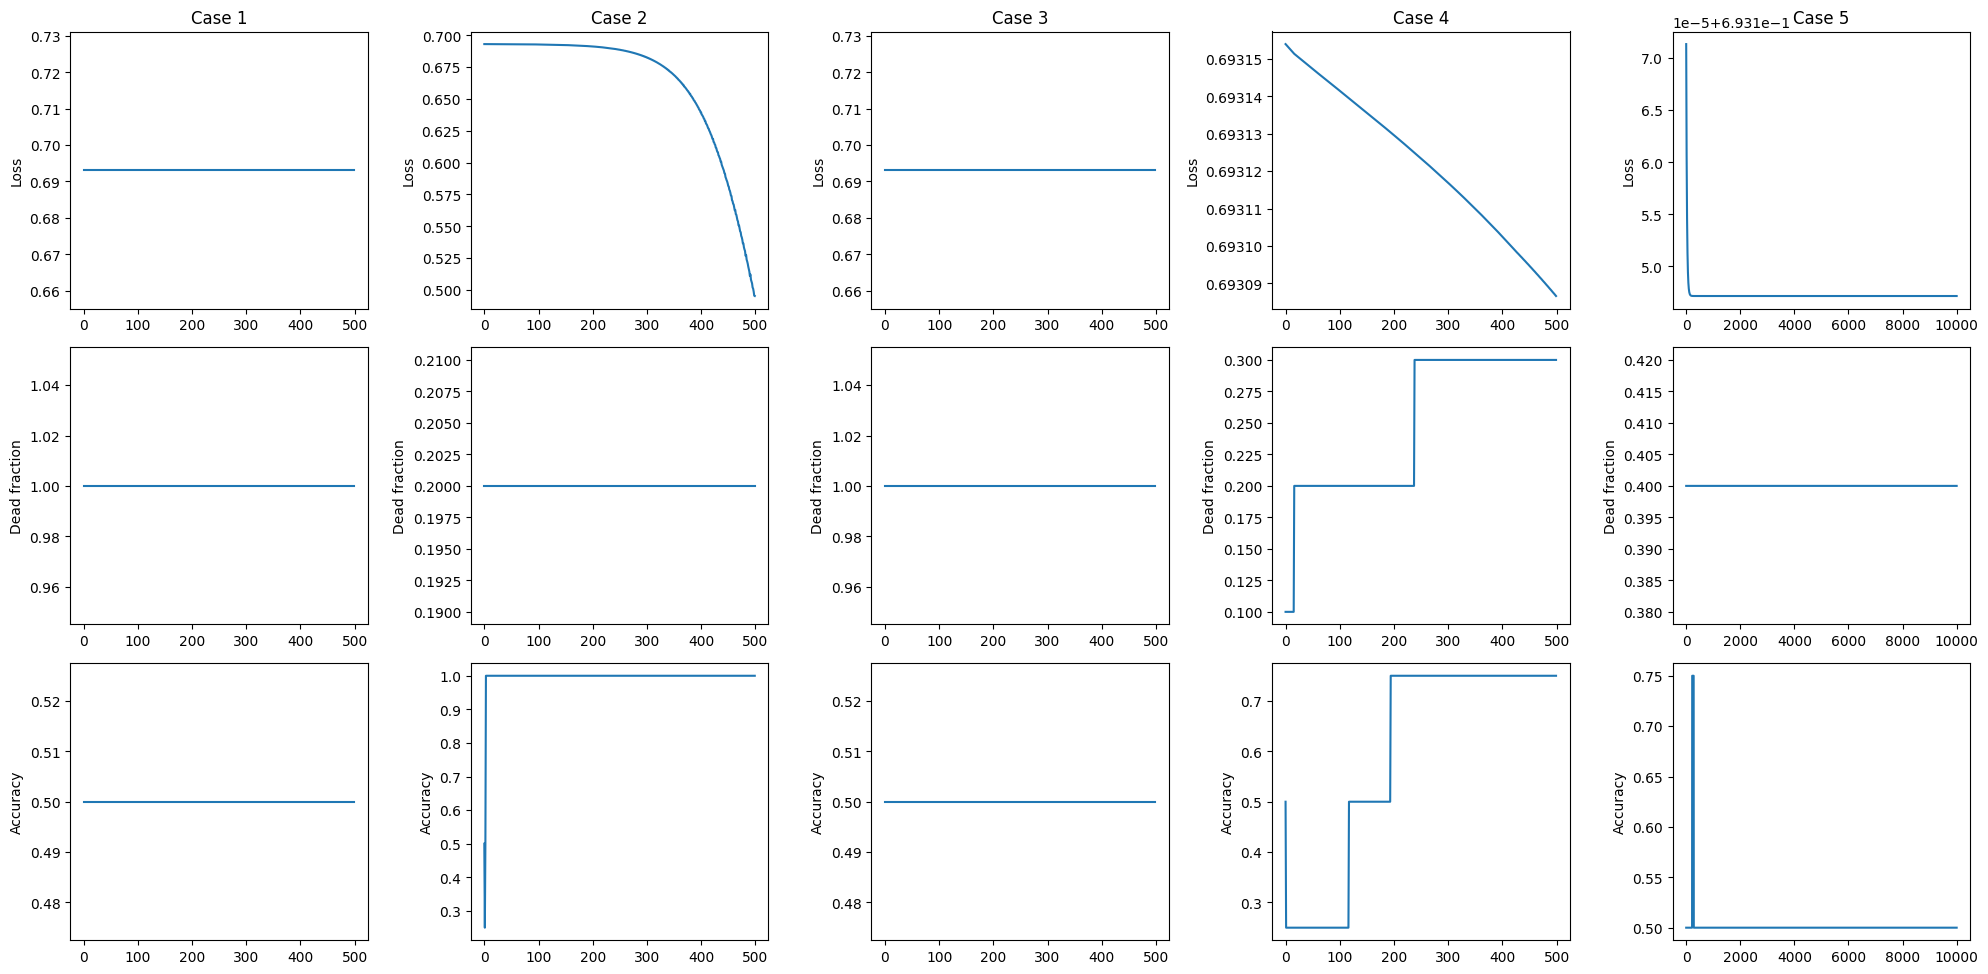

In [ ]:
configs = [
    {"lr":0.1, "bias_init":-5.0, "epochs":500, "random_bias":False, "label":"Case 1"},
    {"lr":0.1, "bias_init":0.0, "epochs":500, "random_bias":False, "label":"Case 2"},
    {"lr":0.01, "bias_init":-5.0, "epochs":500, "random_bias":False, "label":"Case 3"},
    {"lr":0.01, "bias_init":0.0, "epochs":500, "random_bias":False, "label":"Case 4"},
    {"lr":0.01, "bias_init":0.0, "epochs":10000, "random_bias":True, "label":"Case 5"},
]

fig, axes = plt.subplots(3, len(configs), figsize=(20,10))

for i, cfg in enumerate(configs):
    losses, dead_fracs, accs = train(X, y, **cfg)
    
    axes[0,i].plot(losses); axes[0,i].set_title(cfg["label"]); axes[0,i].set_ylabel("Loss")
    axes[1,i].plot(dead_fracs); axes[1,i].set_ylabel("Dead fraction")
    axes[2,i].plot(accs); axes[2,i].set_ylabel("Accuracy")
    
plt.tight_layout()
plt.show()


Case 1 (lr=0.1, bias=-5.0) and Case 3 (lr=0.01, bias=-5.0):     
These show strong dying ReLU behavior. The large negative bias pushes the hidden pre-activations deep into the negative region, so the ReLU outputs are zero for most inputs. Once neurons are stuck at zero, they stop contributing to learning.       

Case 2 (lr=0.1, bias=0.0) and Case 4 (lr=0.01, bias=0.0):       
These exhibit moderate dying ReLU. With zero bias, some neurons may still fall into the negative region depending on weight updates, but fewer than with -5.0 bias.     

Case 5 (lr=0.01, random bias, long training):       
This case typically avoids dying ReLU. Random bias initialization ensures that some neurons start with positive pre-activations, keeping them active. The longer training period also gives the network time to adjust weights without killing too many neurons.        